### Imports

In [1]:
import numpy as np
from sympy import *
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import timeit
from tqdm.notebook import tqdm

import sys
import os
sys.path.append(os.path.abspath('..'))

from generated_kinematics import *
from visualize_rrur import visualize_robot

In [2]:
# Visualize forward kinematics

joint_vector = np.array([np.deg2rad(45), np.deg2rad(135), np.deg2rad(135), np.deg2rad(360 - 60)])
fk_result, loss = forward_kinematics(joint_vector)
print(loss)
visualize_robot(*fk_result[:4], *joint_vector, *fk_result[4:])

KeyboardInterrupt: 

## Sweeping through the joint space

Here we can adjust the joint ranges to cover every permutation of robot configuarations. 10000 exploration points can take around 9 seconds to compute on an AMD Ryzen 9 6900HS Creator Edition (16) cpu

In [3]:
# Define joint limits
theta11_range = np.linspace(np.deg2rad(10), np.deg2rad(70), 10)
theta21_range = np.linspace(np.deg2rad(90), np.deg2rad(128), 10)
theta31_range = np.linspace(np.deg2rad(107.4606), np.deg2rad(170), 10)
theta22_range = np.linspace(np.deg2rad(220), np.deg2rad(290), 10)

# Create empty arrays to store the results
num_points = len(theta11_range) * len(theta21_range) * len(theta31_range) * len(theta22_range)
joint_vectors = np.zeros((num_points, 4))
fk_results = np.zeros((num_points, 4))

# crude way of getting all permutations of joint angles
idx = 0
for j1 in theta11_range:
    for j2 in theta21_range:
        for j3 in theta31_range:
            for j4 in theta22_range:
                joint_vector = [j1, j2, j3, j4]
                joint_vectors[idx] = joint_vector
                
                # Calculate forward kinematics
                fk_result, loss = forward_kinematics(joint_vector)
                
                # Extract position
                fk_results[idx] = fk_result[:4]
                
                idx += 1

print(f"Generated {num_points} points for joint space exploration")
print(f"Shape of joint vectors: {joint_vectors.shape}")
print(f"Shape of end effector positions: {fk_results.shape}")

Generated 10000 points for joint space exploration
Shape of joint vectors: (10000, 4)
Shape of end effector positions: (10000, 4)


In [4]:
# Create an array to store the average positions of E1 and E3
avg_positions = np.zeros((num_points, 3))

# Calculate the end effector positions and average of E1 and E3
for i in range(num_points):
    E1_ee_eval = E1_ee_func(*fk_results[i])
    E3_ee_eval = E3_ee_func(*fk_results[i])
    
    # Calculate average position of E1 and E3
    avg_positions[i] = 0.5 * (E1_ee_eval + E3_ee_eval)

In [5]:
import plotly.graph_objects as go
import plotly.express as px

home_pose = [0, 0, 0, 0.150]  # Define the home pose for the end effector
ik_home, loss = inverse_kinematics(home_pose)

# Create a scatter3d trace for the average positions
fig = visualize_robot(*home_pose, *ik_home, width=800, height=600)

# Add the scatter points with color based on distance from z-axis
fig.add_trace(go.Scatter3d(
    x=avg_positions[:, 0],
    y=avg_positions[:, 1],
    z=avg_positions[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=(avg_positions[:, 0]**2 + avg_positions[:, 1]**2)**0.5,  # heatmap by distance from z-axis
        colorscale='jet',
        opacity=0.2,
        colorbar=dict(title='Distance from z-axis')
    ),
    name='End Effector Positions'
))

# Set the layout
fig.update_layout(margin=dict(l=0, r=50, b=0, t=30))

# Show the figure
fig.show()

# Save the figure as an HTML file
fig.write_html("neck_brace_joint_space_exploration.html")

## End-effector space sweep and animation 

implementing sweep of principle rotation directions

In [2]:
# Visualize inverse kinematics

ee_pose = np.array([np.deg2rad(-50), np.deg2rad(0), np.deg2rad(0), 0.15])
ik_result, loss = inverse_kinematics(ee_pose)
visualize_robot(*ee_pose, *ik_result).show()
pprint(loss)
ik_result

0.0011949152


Array([1.0274101 , 2.0353174 , 2.114182  , 4.667342  , 1.4723375 ,
       4.8108487 , 2.4098775 , 0.3948626 , 2.0460389 , 0.38422567,
       2.4098778 , 0.39486274], dtype=float32)

In [3]:
# Define sweep ranges
alpha_range = np.linspace(np.deg2rad(-60), np.deg2rad(60), 100)
beta_range = np.linspace(np.deg2rad(-35), np.deg2rad(35), 100)
gamma_range = np.linspace(np.deg2rad(-60), np.deg2rad(80), 100)

# Create empty arrays to store the results
num_points = len(alpha_range) + len(beta_range) + len(gamma_range)
poses = np.zeros((num_points, 4))
ik_results = np.zeros((num_points, 12))

In [4]:
idx = 0
for alpha in alpha_range:
    pose = np.array([alpha, 0, 0, 0.150])
    poses[idx, :] = pose
    
    ik_result, loss = inverse_kinematics(pose, x0=ik_x0)

    ik_results[idx, :] = ik_result
    idx += 1


for beta in beta_range:
    pose = np.array([0, beta, 0, 0.150])
    poses[idx, :] = pose

    ik_result, loss = inverse_kinematics(pose, x0=ik_x0)

    ik_results[idx, :] = ik_result
    idx += 1


for gamma in gamma_range:
    pose = np.array([0, 0, gamma, 0.150])
    poses[idx, :] = pose

    ik_result, loss = inverse_kinematics(pose, x0=ik_x0)

    ik_results[idx, :] = ik_result
    idx += 1


theta11: min = 1.0808, max = 69.1497
theta21: min = 89.5128, max = 128.3938
theta31: min = 110.8503, max = 178.9190
theta22: min = 221.7409, max = 293.1710


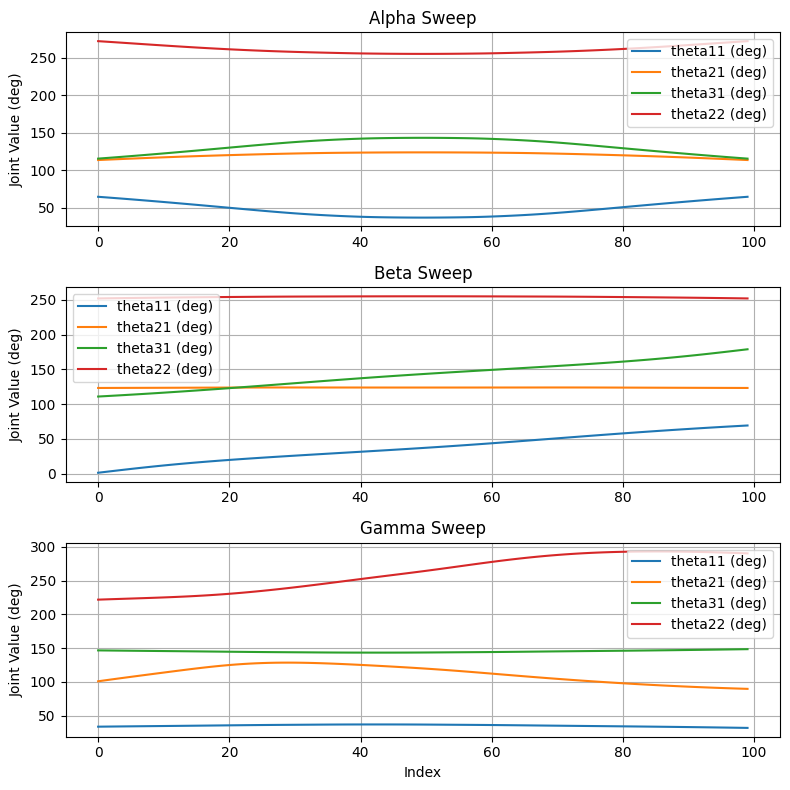

In [12]:
## cross checking inverse kinematics with marlow's code
# Get the min and max values for d1, d2, d3, and theta2 from the first 4 columns of ik_results
theta11_min, theta11_max = ik_results[:, 0].min(), ik_results[:, 0].max()
theta21_min, theta21_max = ik_results[:, 1].min(), ik_results[:, 1].max()
theta31_min, theta31_max = ik_results[:, 2].min(), ik_results[:, 2].max()
theta22_min, theta22_max = ik_results[:, 3].min(), ik_results[:, 3].max()

print(f"theta11: min = {np.rad2deg(theta11_min):.4f}, max = {np.rad2deg(theta11_max):.4f}")
print(f"theta21: min = {np.rad2deg(theta21_min):.4f}, max = {np.rad2deg(theta21_max):.4f}")
print(f"theta31: min = {np.rad2deg(theta31_min):.4f}, max = {np.rad2deg(theta31_max):.4f}")
print(f"theta22: min = {np.rad2deg(theta22_min):.4f}, max = {np.rad2deg(theta22_max):.4f}")


x = np.arange(ik_results.shape[0])
# Segment indices for each sweep
alpha_end = len(alpha_range)
beta_end = alpha_end + len(beta_range)
gamma_end = beta_end + len(gamma_range)

fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=False)

# Alpha sweep
axs[0].plot(np.rad2deg(ik_results[:alpha_end, 0]), label='theta11 (deg)')
axs[0].plot(np.rad2deg(ik_results[:alpha_end, 1]), label='theta21 (deg)')
axs[0].plot(np.rad2deg(ik_results[:alpha_end, 2]), label='theta31 (deg)')
axs[0].plot(np.rad2deg(ik_results[:alpha_end, 3]), label='theta22 (deg)')
axs[0].set_title('Alpha Sweep')
axs[0].set_ylabel('Joint Value (deg)')
axs[0].legend()
axs[0].grid(True)

# Beta sweep
axs[1].plot(np.rad2deg(ik_results[alpha_end:beta_end, 0]), label='theta11 (deg)')
axs[1].plot(np.rad2deg(ik_results[alpha_end:beta_end, 1]), label='theta21 (deg)')
axs[1].plot(np.rad2deg(ik_results[alpha_end:beta_end, 2]), label='theta31 (deg)')
axs[1].plot(np.rad2deg(ik_results[alpha_end:beta_end, 3]), label='theta22 (deg)')
axs[1].set_title('Beta Sweep')
axs[1].set_ylabel('Joint Value (deg)')
axs[1].legend()
axs[1].grid(True)

# Gamma sweep
axs[2].plot(np.rad2deg(ik_results[beta_end:gamma_end, 0]), label='theta11 (deg)')
axs[2].plot(np.rad2deg(ik_results[beta_end:gamma_end, 1]), label='theta21 (deg)')
axs[2].plot(np.rad2deg(ik_results[beta_end:gamma_end, 2]), label='theta31 (deg)')
axs[2].plot(np.rad2deg(ik_results[beta_end:gamma_end, 3]), label='theta22 (deg)')
axs[2].set_title('Gamma Sweep')
axs[2].set_xlabel('Index')
axs[2].set_ylabel('Joint Value (deg)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()


In [20]:
import imageio
import kaleido # requirement for plotly
kaleido.get_chrome_sync() # kaleido needs to sync with Chrome for rendering images
import io

frames = []
    
pbar = tqdm(total=num_points, desc="Processing frames", unit="frame")
for i in range(num_points):
    alpha_val, beta_val, gamma_val, z_val = poses[i]
    theta_11, theta_21, theta_31, theta_22, theta_12, theta_32, gamma_11, gamma_12, gamma_21, gamma_22, gamma_31, gamma_32 = ik_results[i]
    
    fig = visualize_robot(
        *poses[i],
        *ik_results[i]
    )
    

    if i < len(alpha_range):
        fig.update_layout(
            scene_camera=dict(
                eye=dict(x=1.5, y=.5, z=.5) 
            )
        )
    elif i < len(beta_range) + len(alpha_range):
        fig.update_layout(
            scene_camera=dict(
            eye=dict(x=2.0, y=0, z=0.2) # Camera positioned along +x axis, looking toward origin
            )
        )
    else:
        fig.update_layout(
            scene_camera=dict(
                eye=dict(x=0, y=2.0, z=1.0)
            )
        )

    img_bytes = fig.to_image(format="png", engine="kaleido")
    
    image = imageio.v2.imread(io.BytesIO(img_bytes))
    frames.append(image)

    pbar.update(1)


duration = 0.02
imageio.mimsave('axial_rotation.gif', frames[:len(alpha_range)], duration=duration, loop=0)
imageio.mimsave('lateral_bending.gif', frames[len(alpha_range): len(alpha_range) + len(beta_range)], duration=duration, loop=0)
imageio.mimsave('flexion_extension.gif', frames[len(alpha_range) + len(beta_range): len(alpha_range) + len(beta_range) + len(gamma_range)], duration=duration, loop=0)


Processing frames:   0%|          | 0/300 [00:00<?, ?frame/s]